# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish simple **benchmarks** to contextualise the results.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch)](#424-hyperparameter-search-definition-gridsearch)
- [Evaluation & Save Utilities](#evaluation--save-utilities)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
    - [Hexagon Encoding](#hexagon-encoding)
- [Feature Selection](#feature-selection)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [Embed Dimension Search](#embed-dimension-search)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Tuned Deeper — Training](#4212-tuned-deeper--training)
  - [4.2.12 Tuned Deeper — Evaluation](#4212-tuned-deeper--evaluation)
- [4.2.13 Wider Model — Training](#4213-wider-model--training)
  - [4.2.13 Wider Model — Evaluation](#4213-wider-model--evaluation)
- [4.2.14 Hyperparameter Search — Wider Model](#4214-hyperparameter-search--wider-model)
  - [4.2.14 Tuned Wider — Training](#4214-tuned-wider--training)
  - [4.2.14 Tuned Wider — Evaluation](#4214-tuned-wider--evaluation)
  - [Statistical Significance — Wilcoxon Signed-Rank](#statistical-significance--wilcoxon-signed-rank)


In [128]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [129]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [130]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/hexagon/demand_hex_1h_low.parquet")

In [131]:
data

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,862664197ffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.000000,0.000000,0.027498,0.659954
1,2025-01-01 00:00:00,482136,86266419fffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.000000,0.000000,0.027521,0.330253
2,2025-01-01 00:00:00,482136,8626641b7ffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.000000,0.000000,0.000000,0.302173
3,2025-01-01 00:00:00,482136,862664527ffffff,airport,3,3,0.0,1228.000,9.536667,25.916667,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.000000,0.000000,0.000000,0.961182
4,2025-01-01 00:00:00,482136,86266452fffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.054970,0.027485,0.027485,1.346772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289075,2025-12-31 23:00:00,490895,862664dafffffff,residential,0,0,0.0,0.000,0.000000,0.000000,...,3.960234,4.291273,0.000000,0.027329,0.000000,0.000000,0.000000,0.000000,0.000000,0.027329
289076,2025-12-31 23:00:00,490895,862759347ffffff,airport,6,6,157.5,1481.500,15.505000,38.833333,...,2.892475,2.057285,0.136860,1.176998,0.301092,0.520069,0.000000,0.000000,0.027372,2.162392
289077,2025-12-31 23:00:00,490895,86275934fffffff,airport,8,8,165.0,1635.875,15.167500,38.625000,...,1.220338,2.809967,0.191761,1.068385,0.465706,0.383523,0.000000,0.000000,0.027394,2.136770
289078,2025-12-31 23:00:00,490895,86275935fffffff,airport,4,4,140.0,1582.750,13.910000,36.125000,...,1.340206,7.539746,0.054799,0.273996,0.054799,0.027400,0.000000,0.000000,0.000000,0.410994


## 4.2.1 Data Information

In [132]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each hexagon + hour-of-day combination appear?
hex_hour_counts = data.groupby(['pickup_h3_res6', 'hour_of_day']).size()

print(f"\n--- Hexagon × Hour-of-day ---")
print(f"Unique hex × hour combinations : {len(hex_hour_counts):>8,}")
print(f"Avg appearances per combo      : {hex_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {hex_hour_counts.min():>8,}")
print(f"Max appearances                : {hex_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    289,080
Unique combinations (no time) :    289,080
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  289,080 combinations

--- Hexagon × Hour-of-day ---
Unique hex × hour combinations :      792
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :   91,126  (31.5%)
Non-zero-demand rows           :  197,954  (68.5%)


In [133]:
data.head()

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.00000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.00000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.00000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,3,3,0.0,1228.0,9.536667,25.916667,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.00000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,0,0,0.0,0.0,0.000000,0.000000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.05497,0.027485,0.027485,1.346772


## 4.2.2 Model Configurations

In [134]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# --- optimization ---
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0     # decoupled L2 (AdamW); per-arch values come from the HP search
BATCH_SIZE         = 1024
MAX_EPOCHS         = 300

# --- loss / output ---
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll" (count NLLs: raw-count targets, log-rate output)
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# --- layer defaults ---
HIDDEN_ACTIVATION  = "relu"  # "relu" | "sigmoid"
WEIGHT_INIT        = "he_normal"

# --- early stopping ---
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# --- data handling ---
SPLIT              = "random"
SCALER_FIT_ON      = "train_only"

# --- hex embedding ---
HEX_EMBED_DIM      = 16      # learned embedding dim per hexagon

# --- device ---
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- reproducibility ---
SEEDS              = (0,)

# --- architectures ---
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    HIDDEN_ACTIVATION = HIDDEN_ACTIVATION,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    HEX_EMBED_DIM  = HEX_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4, 2e-3, 5e-3, 8e-3, 2e-2, 5e-2, 8e-2]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))           # step 2: multipliers inside the winning decade


## 4.2.3 Model Definition

In [135]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_hex, embed_dim):
        super().__init__()
        self.hex_embed = nn.Embedding(n_hex, embed_dim)
        nn.init.normal_(self.hex_embed.weight, std=0.01)

        _act_name = getattr(config, "HIDDEN_ACTIVATION", "relu").lower()
        _act_cls  = {"relu": nn.ReLU, "sigmoid": nn.Sigmoid}[_act_name]

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            if _act_name == "relu":
                nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            else:
                nn.init.xavier_normal_(linear.weight)   # gain-matched for saturating activations
            nn.init.zeros_(linear.bias)
            layers += [linear, _act_cls()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, hex_idx):
        emb = self.hex_embed(hex_idx)          # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)      # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _embed_dim  = embed_dim  if embed_dim  is not None else config.HEX_EMBED_DIM
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_HEX, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train,   dtype=torch.float32),
            torch.as_tensor(hex_train, dtype=torch.long),
            torch.as_tensor(y_train,   dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t   = torch.as_tensor(X_val,   dtype=torch.float32).to(device)
    hex_val_t = torch.as_tensor(hex_val, dtype=torch.long).to(device)
    y_val_t   = torch.as_tensor(y_val,   dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, hb, yb in train_dl:
            xb, hb, yb = xb.to(device), hb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, hb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, hex_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch using Optuna)

Two-step search→fine grid search (Optuna `GridSampler`):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, three representative values
   per decade to locate the best decade of the learning rate for the finer hyperparameter search.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade from step 1.
    - e.g. decade step 1 identified 1e-3 to be the best decade, then [1e-3, 2e-3, ..., 9e-3] are evaluated to find the best LR.

This way only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result.

In [136]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  hex_train, hex_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model per seed in HP_SEARCH_SEEDS and is
    scored by the mean validation loss, so the search is reproducible.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        hex_train, hex_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades. Both steps are exhaustive grids, so
    only rough orders of magnitude need to be known upfront."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           hex_train, hex_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         hex_train, hex_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers functions: `evaluate_models` computes the test-set metrics for the models and returns the result rows, `save_results` appends them to the results CSV.

In [137]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, hex_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        # test loss under the training criterion, so train/val/test are comparable
        _y_target = y_test if IS_POISSON else y_test_log
        if config.LOSS == "mae":
            _test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
        elif config.LOSS == "mse":
            _test_loss = float(np.mean((preds_raw - _y_target) ** 2))
        elif config.LOSS == "poisson_nll":
            _test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
        else:  # nb_nll — evaluate with the model's trained dispersion
            _test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                           torch.as_tensor(_y_target, dtype=torch.float32),
                                           model.log_theta.detach().cpu()))
        test_losses.append(_test_loss)

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "optimizer"         : getattr(config, "OPTIMIZER", "adam"),
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")

    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")


    print(f"\n--- overfitting check ({config.LOSS}, {'raw counts' if IS_POISSON else 'log1p scale'}) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [138]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_1h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

The values below are illustrative (schematic), not a specific record.

```
One row of raw data  —  one hexagon in one 1 h bucket
┌─────────────────────┬───────────────────────────────────┬─────────────┐
│   pickup_h3_res6    │ is_weekend, month_sin, area_km2,  │ trip_count  │
│  '862664cc7ffffff'  │    1,       0.50,     36.4, …     │      5      │
└──────────┬──────────┴─────────────────┬─────────────────┴──────┬──────┘
           │                            │                        │
           ▼                            ▼                        ▼
       hex_vocab                 StandardScaler             np.log1p(y)
   '862664cc7ffffff'         [1.59, 0.40, -0.51, …]            1.79
         → 17              (n_num dims, fit on train)    (training target)
           │                            │
           ▼                            │
 Embedding table                        │
 (N_HEX rows × HEX_EMBED_DIM)           │
 row 17: [0.12, -0.31, …]               │
           │                            │
           └─────────────┬──────────────┘
                         ▼
                 torch.cat(x, emb)
          [0.12, -0.31, …, 1.59, 0.40, …]
           (HEX_EMBED_DIM + n_num dims)
                         │
                         ▼
          ┌─────────────────────────────┐
          │  Linear(dim → 64)           │
          │  ReLU                       │   ← 2 blocks × 64   (baseline)
          │  Linear(64 → 64)            │      2 blocks × 256 (wider)
          │  ReLU                       │      8 blocks × 64  (deeper)
          │  Linear(64 → 1)             │
          │  Softplus                   │   ← keeps the log1p output ≥ 0
          └─────────────────────────────┘
                         │
                         ▼
         ŷ_log   (predicted log1p demand)
                         │
                         ▼  np.expm1(ŷ_log) ← evaluation only, never in the loss
          ŷ   (predicted trip count, ≥ 0)
```

**Target scale.** The network is trained on `log1p(trip_count)`, so both the `Softplus` output and
the training criterion (`config.LOSS = "mae"`) live on the log1p scale — `Softplus` is what keeps
the back-transformed prediction non-negative. Raw trip counts reappear only at evaluation time,
where `expm1` inverts the transform before evaluation metrics are computed.

**Hexagon embedding.** The table holds one row per hexagon seen in training
plus one reserved *unknown* row for hexagons that appear only in val/test. It
starts with near-zero weights and is updated by backprop alongside all other parameters, so the
network learns which hexagons behave similarly. `HEX_EMBED_DIM` is not fixed upfront: the embed
dimension search below selects it from `[8, 16, 32]`.

## 4.2.6 Train / Val / Test Split

We split rows chronologically into **70 % train / 15 % val / 15 % test** using
`train_test_split`.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [139]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :   202,356 rows
Val   :    43,362 rows
Test  :    43,362 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.

We split the features into LEAKAGE, CYCLIC, ID and TARGET columns to have a better overview of how the FEATURE columns are composed. All three column types: LEAKAGE, RAW_CYCLIC, ID are removed since they are not relevant for our models.
- LEAKAGE contain the columns that need to be removed, either because they leak undesired information into our models (e.g. idle_time, avg_tip etc.), or because they do not add any informational value or even harm the model
- RAW_CYCLIC are the raw temporal columns that have not been transformed (transformed columns are included in FEATURE column)
- ID contains columns we need to remove, e.g. bucket_index or pickup_h3_res6


#### Hexagon Encoding

Hexagon identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network.

In [140]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    # trip-derived aggregates from the same time bucket -> target leakage
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]

# Non-leakage columns we deliberately drop, based on the two selection cells
# above (correlation matrix + model-based / permutation importance).
# The SAME set is used for every hexagon temporal resolution (1h / 2h / 6h / 24h)
# so all four models share one feature space.
DROP_COLS = [
    'is_rush_hour',                              # redundant with the cyclic hour encoding (r=-0.82 with hour_of_day_sin); constant at 24h
    # weather: negligible importance and hurts CV (see manual-testing note)
    'temperature_2m', 'apparent_temperature',   # r=+0.99 with each other
    'rain', 'precipitation',                     # r=+0.99 with each other
    'wind_speed_10m', 'cloud_cover', 'snowfall',
    'is_day',                                    # r=-0.96 with month_cos (season / daylight proxy)
    # redundant POI density: |r| >= 0.8 with poi_density_total_per_km2, kept as the strongest POI signal for hexagons
    'train_station_per_km2',                     # r=+0.83 with poi_density_total_per_km2
    'restaurants_per_km2',                       # r=+0.99 with poi_density_total_per_km2
    'attractions_per_km2',                       # r=+0.92 with poi_density_total_per_km2
    'bars_and_clubs_per_km2',                    # r=+0.96 with poi_density_total_per_km2
    'universities_per_km2',                      # r=+0.84 poi_density / +0.88 hotels
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + DROP_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Numeric features (22): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'apparent_temperature', 'precipitation', 'snowfall', 'cloud_cover', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']
Target scale : raw counts (count NLL)
Unique hexagons (train) : 33  |  embed dim : 16
Unseen hexes  val: 0   test: 0

X_train : (202356, 22)   y_train : (202356,)
X_val   : (43362, 22)     y_val   : (43362,)
X_test  : (43362, 22)    y_test  : (43362,)


## Feature Selection

We base our decision of feature selection on two selection methods:

1. correlation matrix
2. model-based feature importance

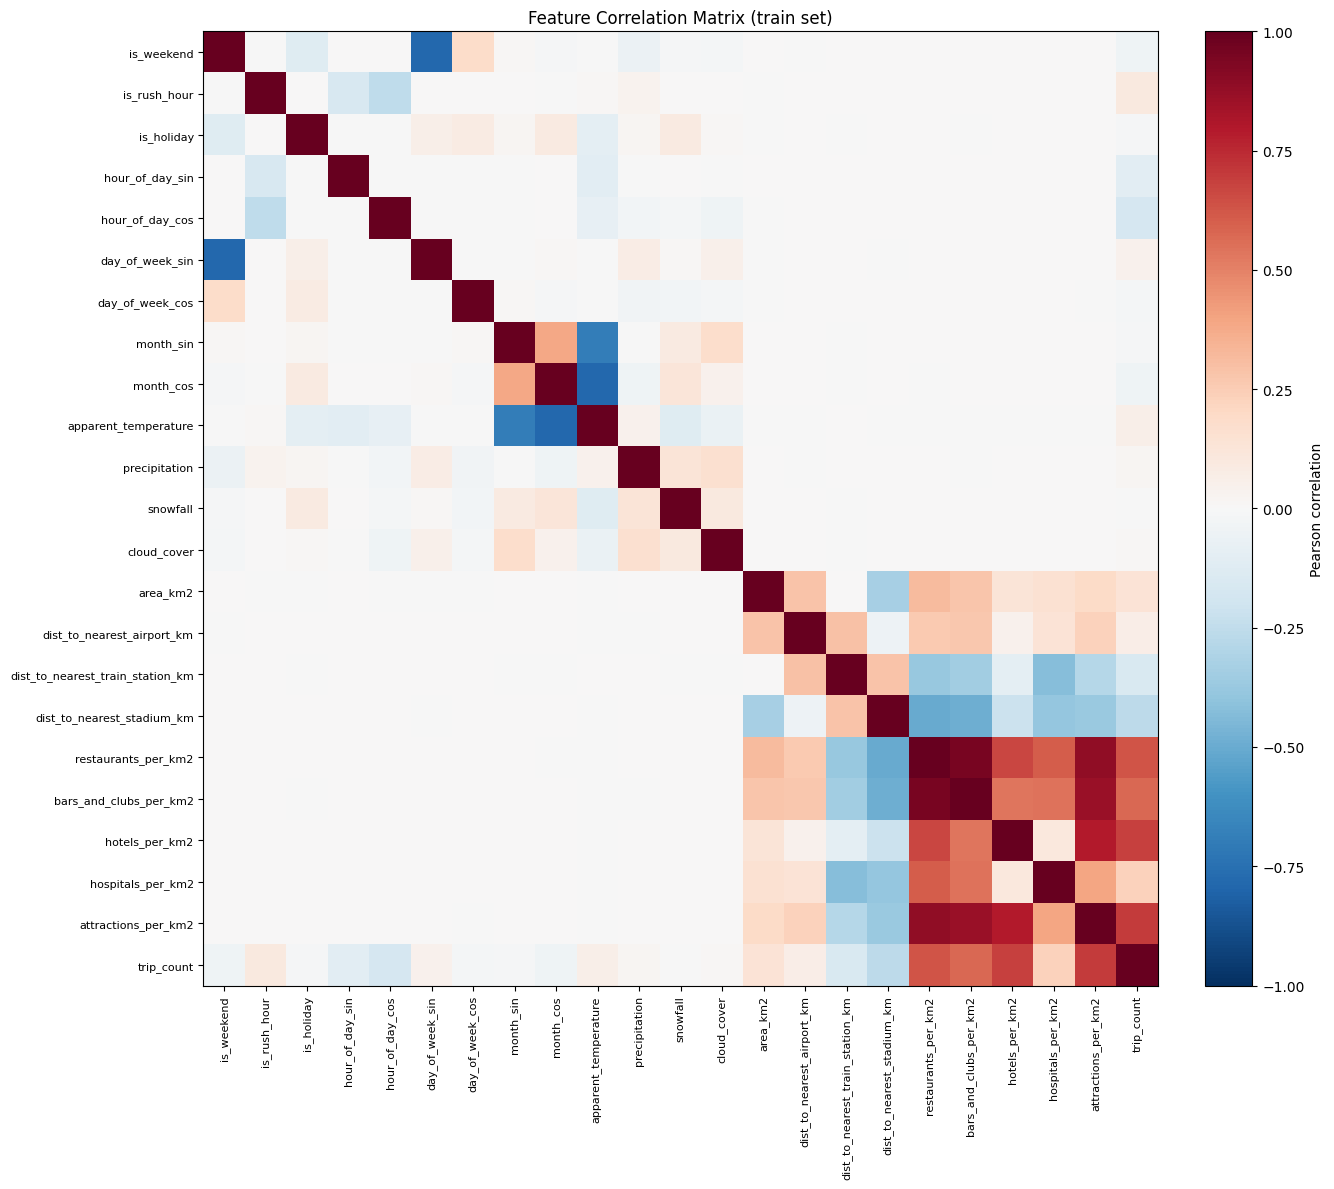

Feature pairs with |correlation| >= 0.8:
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.952
  restaurants_per_km2                 vs attractions_per_km2                  r=+0.888
  bars_and_clubs_per_km2              vs attractions_per_km2                  r=+0.863


In [141]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [142]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                 hour_of_day_cos       0.200459         0.474581             0.004704
                 hour_of_day_sin       0.114061         0.239469             0.004589
             attractions_per_km2       0.187357         0.235216             0.001639
             restaurants_per_km2       0.171551         0.179105             0.001430
                  hotels_per_km2       0.164777         0.138667             0.001338
      dist_to_nearest_airport_km       0.023998         0.062556             0.000233
                 day_of_week_sin       0.029074         0.051390             0.000808
          bars_and_clubs_per_km2       0.037488         0.037512             0.000183
                       month_cos       0.014855         0.027579             0.000773
                      is_weekend       0.018366         0.021609             0.000501
                 day_of_week_cos       0.005652       

### **Final drop list**

*Applied identically across all hexagon resolutions (1h / 2h / 6h / 24h) so the four models share one feature space.*

- `is_rush_hour`
- `temperature_2m`
- `apparent_temperature`
- `rain`
- `precipitation`
- `wind_speed_10m`
- `cloud_cover`
- `snowfall`
- `is_day`
- `train_station_per_km2`
- `restaurants_per_km2`
- `attractions_per_km2`
- `bars_and_clubs_per_km2`
- `universities_per_km2`

#### **Retained (15)**

- Temporal: `is_weekend`, `is_holiday`, `hour_of_day_sin`, `hour_of_day_cos`, `day_of_week_sin`, `day_of_week_cos`, `month_sin`, `month_cos`
- Distance: `dist_to_nearest_airport_km`, `dist_to_nearest_train_station_km`, `dist_to_nearest_stadium_km`
- POI density: `poi_density_total_per_km2`, `hotels_per_km2`, `hospitals_per_km2`
- Area: `area_km2`

#### **Cyclic hour encoding**

- `hour_of_day_sin`, `hour_of_day_cos` are the strongest predictors at fine resolution (permutation importance ≈ 0.47 / 0.24 at 1h), so they are kept for every resolution. At 24h there is exactly one row per hexagon per day, so they are constant — inert after scaling — but retained so the feature space is identical across resolutions.
- `is_rush_hour` — dropped: weak (perm ≈ 0.003) and r=−0.82 with `hour_of_day_sin`, i.e. redundant with the cyclic encoding; constant at 24h.

#### **Weather (dropped as a block)**

- Manual testing showed removing weather improved results across the board, and the model-based importances agree (permutation importance ≈ 0.0002 – 0.007). `temperature_2m`/`apparent_temperature` (r=0.99) and `rain`/`precipitation` (r=0.99) are additionally mutually redundant.

#### **Season proxy**

- `is_day` — r=−0.96 with `month_cos` (and with `hour_of_day_cos` at sub-daily resolution); a daylight/season proxy, dropped in favour of the direct cyclic encodings.

#### **POI density cluster (r ≥ 0.8)**

- The density columns are mutually collinear (`restaurants` r=0.99 with `poi_density_total`, `bars_and_clubs` 0.96, `attractions` 0.92, `universities` 0.84, `train_station` 0.83). For hexagons `poi_density_total_per_km2` is the single strongest POI signal (permutation importance ≈ 0.12, top of the POI group), so we resolve the cluster by keeping the aggregate:
    - Keep `poi_density_total_per_km2` and `hotels_per_km2` (not collinear with the total — only paired with `universities` at r=0.88)
    - Drop the components collinear with the kept total: `train_station_per_km2`, `restaurants_per_km2`, `attractions_per_km2`, `bars_and_clubs_per_km2`, and `universities_per_km2`
    - `hospitals_per_km2` is not in any r ≥ 0.8 pair, so it is retained as an independent density signal
    - Note: RF importance is split across the correlated group anyway (impurity importance dilutes across collinear features), so an individual component's rank is not evidence it is uniquely informative

## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each hexagon × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat the benchmark models is not adding value for our business client. In that case the decision is fixed: the model should not be implemented and the benchmark should be chosen as their prediction model.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [143]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_h3_res6', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_h3_res6', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_h3_res6', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (hex × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691

Historical mean (hex × hour)         R²=0.8329  MAE=7.2371  RMSE=22.9434  NRMSE=1.3059  MAPE=84.6%
Ridge regression                     R²=0.5927  MAE=13.2325  RMSE=35.8214  NRMSE=2.0389  MAPE=246.1%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (with early stopping).

In [144]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
HEX_EMBED_DIM        = best_embed_dim
config.HEX_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {HEX_EMBED_DIM}  →  set as global HEX_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=5

  embed_dim=  8  val_loss=2.2335
  embed_dim= 16  val_loss=2.2423
  embed_dim= 32  val_loss=2.2307

Best embed_dim: 32  →  set as global HEX_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` and report
the validation loss.


In [145]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_HEX, HEX_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
h_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, h_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 22]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   1,088
├─Sequential: 1-2                        [1, 54]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 54]                   [1, 64]                   3,520
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 8,834
Trainable params: 8,834
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 22]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   1,088
├─Sequential: 1-2                        [1, 54]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 54]                   [1, 64]                   3,520
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 8,834
Trainable params: 8,834
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

In [146]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/300
  loss: 4.0168  val_loss: 3.2543 ✓
Epoch   2/300
  loss: 3.2129  val_loss: 3.1467 ✓
Epoch   3/300
  loss: 3.1338  val_loss: 3.0809 ✓
Epoch   4/300
  loss: 3.0758  val_loss: 3.0315 ✓
Epoch   5/300
  loss: 3.0317  val_loss: 2.9925 ✓
Epoch   6/300
  loss: 2.9972  val_loss: 2.9610 ✓
Epoch   7/300
  loss: 2.9694  val_loss: 2.9353 ✓
Epoch   8/300
  loss: 2.9470  val_loss: 2.9140 ✓
Epoch   9/300
  loss: 2.9281  val_loss: 2.8959 ✓
Epoch  10/300
  loss: 2.9130  val_loss: 2.8807 ✓
Epoch  11/300
  loss: 2.9001  val_loss: 2.8675 ✓
Epoch  12/300
  loss: 2.8891  val_loss: 2.8559 ✓
Epoch  13/300
  loss: 2.8796  val_loss: 2.8460 ✓
Epoch  14/300
  loss: 2.8714  val_loss: 2.8372 ✓
Epoch  15/300
  loss: 2.8642  val_loss: 2.8292 ✓
Epoch  16/300
  loss: 2.8576  val_loss: 2.8221 ✓
Epoch  17/300
  loss: 2.8516  val_loss: 2.8156 ✓
Epoch  18/300
  loss: 2.8462  val_loss: 2.8097 ✓
Epoch  19/300
  loss: 2.8413  val_loss: 2.8042 ✓
Epoch  20/300
  loss: 2.8368  val_loss: 2.7991 ✓
Epoch  

### 4.2.9 Baseline Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [147]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, hex_test,
    device=device, show_weight_stats=True,
)

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0 layer weight stats:
    hex_embed.weight  shape=(34, 32)      max|w|=0.3054  mean|w|=0.0376  norm=1.7547
    net.0.weight    shape=(64, 54)      max|w|=0.9119  mean|w|=0.1563  norm=11.5573
    net.2.weight    shape=(64, 64)      max|w|=0.6565  mean|w|=0.1421  norm=11.4092
    net.4.weight    shape=(1, 64)       max|w|=0.5789  mean|w|=0.1931  norm=1.9281
  seed=0  R²=0.7410  MAE=7.9256  NRMSE=1.6258  MAPE=69.2%  | zeros 10,263/15,505  false=1,332  | pred min=0.0 max=1015.1

--- original scale ---
Baseline  R²    : 0.7410 ± 0.0000
Baseline  MAE   : 7.9256 ± 0.0000
Baseline  RMSE  : 28.5637 ± 0.0000
Baseline  NRMSE : 1.6258 ± 0.0000
Baseline  MAPE  : 69.15% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 10263.0 ± 0.0  (out of 15,505)
Baseline  False-zero   : 1332.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range ---
Baseline  Pred min

In [148]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (28 columns)
          timestamp training_loss optimizer    model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual      r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation      mape
2026-07-20T15:00:27        nb_nll       sgd baseline         2     64        0.00005           0.0        1024     0  2.230666              15505    17.569093 0.74102 7.925565 28.563714 1.625793 0.864245 0.418015  0.553014   0.400824         10263        1332  0.012103 1015.13916                   NaN              relu 69.151634


## 4.2.10 Hyperparameter Search — Baseline Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_BASELINE]`.


In [149]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      2.1204  complete
   2    5.00e-05    0.00e+00      2.2307  complete
   3    2.00e-03    5.00e-03      2.1876  complete
   4    5.00e-03    5.00e-03      2.1147  complete
   5    8.00e-03    0.00e+00      2.1015  complete
   6    2.00e-02    5.00e-04      2.2027  pruned
   7    8.00e-03    5.00e-03      2.0989  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      2.9658  pruned
  10    8.00e-05    5.00e-03      2.8898  pruned
  11    8.00e-05    5.00e-02      2.8967  pruned
  12    5.00e-03    5.00e-02      2.2207  pruned
  13    8.00e-03    5.00e-04      2.1701  pruned
  14    2.00e-03    5.00e-02      2.3555  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03 

{'lr': 0.009, 'weight_decay': 0.003}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.


In [150]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.009, 'weight_decay': 0.003}

Epoch   1/300
  loss: 3.0361  val_loss: 2.5687 ✓
Epoch   2/300
  loss: 2.3265  val_loss: 2.2397 ✓
Epoch   3/300
  loss: 2.1534  val_loss: 2.1919 ✓
Epoch   4/300
  loss: 2.1124  val_loss: 2.2137  (no improvement 1/10)
Epoch   5/300
  loss: 2.0912  val_loss: 2.2449  (no improvement 2/10)
Epoch   6/300
  loss: 2.0693  val_loss: 2.2360  (no improvement 3/10)
Epoch   7/300
  loss: 2.0602  val_loss: 2.1475 ✓
Epoch   8/300
  loss: 2.0509  val_loss: 2.2062  (no improvement 1/10)
Epoch   9/300
  loss: 2.0440  val_loss: 2.1390 ✓
Epoch  10/300
  loss: 2.0389  val_loss: 2.1710  (no improvement 1/10)
Epoch  11/300
  loss: 2.0332  val_loss: 2.1624  (no improvement 2/10)
Epoch  12/300
  loss: 2.0288  val_loss: 2.1554  (no improvement 3/10)
Epoch  13/300
  loss: 2.0245  val_loss: 2.1271 ✓
Epoch  14/300
  loss: 2.0263  val_loss: 2.0855 ✓
Epoch  15/300
  loss: 2.0219  val_loss: 2.1356  (no improvement 1/10)
Epoch  16/300
  loss: 2.0194  val_loss: 2.1021  (n

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [151]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8439  MAE=6.5482  NRMSE=1.2622  MAPE=70.4%  | zeros 9,949/15,505  false=981  | pred min=0.0 max=553.0

--- original scale ---
Tuned Baseline  R²    : 0.8439 ± 0.0000
Tuned Baseline  MAE   : 6.5482 ± 0.0000
Tuned Baseline  RMSE  : 22.1751 ± 0.0000
Tuned Baseline  NRMSE : 1.2622 ± 0.0000
Tuned Baseline  MAPE  : 70.42% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 9949.0 ± 0.0  (out of 15,505)
Tuned Baseline  False-zero   : 981.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range ---
Tuned Baseline  Pred min : 0.0066 ± 0.0000
Tuned Baseline  Pred max : 553.0383 ± 0.0000  (actual max: 746.0000)


In [152]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (28 columns)
          timestamp training_loss optimizer          model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2     mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min  pred_max  overfitting_measures hidden_activation      mape
2026-07-20T15:13:19        nb_nll       sgd baseline_tuned         2     64          0.009         0.003        1024     0  2.085525              15505    17.569093 0.843913 6.54821 22.175105 1.262166 0.874646 0.393722  0.531408   0.385164          9949         981  0.006608 553.03833                   NaN              relu 70.421441


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (8 hidden layers, 64 units)`.
Width is fixed; depth increased (x4) relative to the baseline.


In [153]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/300
  loss: 3.4483  val_loss: 3.3472 ✓
Epoch   2/300
  loss: 3.1722  val_loss: 3.1976 ✓
Epoch   3/300
  loss: 3.0698  val_loss: 3.1012 ✓
Epoch   4/300
  loss: 3.0003  val_loss: 3.0348 ✓
Epoch   5/300
  loss: 2.9519  val_loss: 2.9883 ✓
Epoch   6/300
  loss: 2.9176  val_loss: 2.9537 ✓
Epoch   7/300
  loss: 2.8920  val_loss: 2.9272 ✓
Epoch   8/300
  loss: 2.8716  val_loss: 2.9064 ✓
Epoch   9/300
  loss: 2.8549  val_loss: 2.8891 ✓
Epoch  10/300
  loss: 2.8405  val_loss: 2.8740 ✓
Epoch  11/300
  loss: 2.8276  val_loss: 2.8609 ✓
Epoch  12/300
  loss: 2.8163  val_loss: 2.8490 ✓
Epoch  13/300
  loss: 2.8059  val_loss: 2.8381 ✓
Epoch  14/300
  loss: 2.7963  val_loss: 2.8279 ✓
Epoch  15/300
  loss: 2.7872  val_loss: 2.8182 ✓
Epoch  16/300
  loss: 2.7787  val_loss: 2.8094 ✓
Epoch  17/300
  loss: 2.7711  val_loss: 2.8011 ✓
Epoch  18/300
  loss: 2.7636  val_loss: 2.7927 ✓
Epoch  19/300
  loss: 2.7564  val_loss: 2.7854 ✓
Epoch  20/300
  loss: 2.7491  val_loss: 2.7783 ✓
Epoch  21/300
  loss

### 4.2.11 Deeper Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [154]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper Model — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.7828  MAE=7.6294  NRMSE=1.4890  MAPE=76.7%  | zeros 9,840/15,505  false=1,146  | pred min=0.0 max=978.5

--- original scale ---
Deep  R²    : 0.7828 ± 0.0000
Deep  MAE   : 7.6294 ± 0.0000
Deep  RMSE  : 26.1606 ± 0.0000
Deep  NRMSE : 1.4890 ± 0.0000
Deep  MAPE  : 76.68% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 9840.0 ± 0.0  (out of 15,505)
Deep  False-zero   : 1146.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range ---
Deep  Pred min : 0.0027 ± 0.0000
Deep  Pred max : 978.4896 ± 0.0000  (actual max: 746.0000)


In [155]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (28 columns)
          timestamp training_loss optimizer model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation      mape
2026-07-20T15:16:56        nb_nll       sgd  deep         8     64        0.00005           0.0        1024     0  2.204576              15505    17.569093 0.782764 7.629438 26.160574 1.489011 0.850494 0.428456  0.580347   0.420635          9840        1146  0.002673 978.489624                   NaN              relu 76.677811


## 4.2.12 Hyperparameter Search — Deeper Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_DEEPER]`.


In [156]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      2.0867  complete
   2    5.00e-05    0.00e+00      2.2670  complete
   3    2.00e-03    5.00e-03      2.1166  complete
   4    5.00e-03    5.00e-03      2.0750  complete
   5    8.00e-03    0.00e+00      2.0790  complete
   6    2.00e-02    5.00e-04      2.0589  complete
   7    8.00e-03    5.00e-03      2.0875  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      2.9601  pruned
  10    8.00e-05    5.00e-03      2.8818  pruned
  11    8.00e-05    5.00e-02      2.8879  pruned
  12    5.00e-03    5.00e-02      2.1835  pruned
  13    8.00e-03    5.00e-04      2.0875  complete
  14    2.00e-03    5.00e-02      2.2382  pruned
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.02, 'weight_decay': 0.0005}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above,
across all `SEEDS` for a stable mean ± std estimate.

In [157]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.02, 'weight_decay': 0.0005}

Epoch   1/300
  loss: 2.9381  val_loss: 2.2488 ✓
Epoch   2/300
  loss: 2.1865  val_loss: 2.1582 ✓
Epoch   3/300
  loss: 2.0950  val_loss: 2.1232 ✓
Epoch   4/300
  loss: 2.0580  val_loss: 2.1839  (no improvement 1/10)
Epoch   5/300
  loss: 2.0500  val_loss: 2.1376  (no improvement 2/10)
Epoch   6/300
  loss: 2.0498  val_loss: 2.1004 ✓
Epoch   7/300
  loss: 2.0270  val_loss: 2.1557  (no improvement 1/10)
Epoch   8/300
  loss: 2.0272  val_loss: 2.0959 ✓
Epoch   9/300
  loss: 2.0185  val_loss: 2.1886  (no improvement 1/10)
Epoch  10/300
  loss: 2.0167  val_loss: 2.0933 ✓
Epoch  11/300
  loss: 2.0142  val_loss: 2.0669 ✓
Epoch  12/300
  loss: 2.0200  val_loss: 2.0677  (no improvement 1/10)
Epoch  13/300
  loss: 2.0058  val_loss: 2.0589 ✓
Epoch  14/300
  loss: 2.0044  val_loss: 2.2334  (no improvement 1/10)
Epoch  15/300
  loss: 2.0066  val_loss: 2.0950  (no improvement 2/10)
Epoch  16/300
  loss: 2.0011  val_loss: 2.1824  (no improvement 3/10)
E

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [158]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8589  MAE=6.3586  NRMSE=1.2000  MAPE=67.7%  | zeros 10,811/15,505  false=1,361  | pred min=0.0 max=633.1

--- original scale ---
Tuned Deeper  R²    : 0.8589 ± 0.0000
Tuned Deeper  MAE   : 6.3586 ± 0.0000
Tuned Deeper  RMSE  : 21.0827 ± 0.0000
Tuned Deeper  NRMSE : 1.2000 ± 0.0000
Tuned Deeper  MAPE  : 67.73% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 10811.0 ± 0.0  (out of 15,505)
Tuned Deeper  False-zero   : 1361.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range ---
Tuned Deeper  Pred min : 0.0016 ± 0.0000
Tuned Deeper  Pred max : 633.0516 ± 0.0000  (actual max: 746.0000)


In [159]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (28 columns)
          timestamp training_loss optimizer      model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation      mape
2026-07-20T15:26:16        nb_nll       sgd deep_tuned         8     64           0.02        0.0005        1024     0  2.058917              15505    17.569093 0.858913 6.358571 21.082666 1.199986 0.88371 0.370872  0.511834   0.370977         10811        1361  0.001631 633.051636                   NaN              relu 67.725994


## 4.2.13 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 256 units)`.
Depth is fixed; width increased (x4) relative to the baseline.


In [160]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/300
  loss: 3.7276  val_loss: 3.1481 ✓
Epoch   2/300
  loss: 3.0607  val_loss: 3.0021 ✓
Epoch   3/300
  loss: 2.9619  val_loss: 2.9265 ✓
Epoch   4/300
  loss: 2.9067  val_loss: 2.8796 ✓
Epoch   5/300
  loss: 2.8714  val_loss: 2.8487 ✓
Epoch   6/300
  loss: 2.8484  val_loss: 2.8286 ✓
Epoch   7/300
  loss: 2.8318  val_loss: 2.8118 ✓
Epoch   8/300
  loss: 2.8192  val_loss: 2.7994 ✓
Epoch   9/300
  loss: 2.8095  val_loss: 2.7892 ✓
Epoch  10/300
  loss: 2.8014  val_loss: 2.7811 ✓
Epoch  11/300
  loss: 2.7945  val_loss: 2.7742 ✓
Epoch  12/300
  loss: 2.7883  val_loss: 2.7679 ✓
Epoch  13/300
  loss: 2.7827  val_loss: 2.7618 ✓
Epoch  14/300
  loss: 2.7771  val_loss: 2.7567 ✓
Epoch  15/300
  loss: 2.7723  val_loss: 2.7519 ✓
Epoch  16/300
  loss: 2.7674  val_loss: 2.7468 ✓
Epoch  17/300
  loss: 2.7629  val_loss: 2.7424 ✓
Epoch  18/300
  loss: 2.7584  val_loss: 2.7384 ✓
Epoch  19/300
  loss: 2.7539  val_loss: 2.7342 ✓
Epoch  20/300
  loss: 2.7494  val_loss: 2.7301 ✓
Epoch  21/300
  loss

### 4.2.13 Wider Model — Evaluation

Evaluate on the held-out **test set** using the best-checkpoint model from each
seed, then report mean ± std across seeds.

Metrics:
- **Zero-demand rows** — share of test rows with `trip_count = 0` (context for inflated R²)
- **Mean Actual Test Demand** — average true trip count in the test set
- **R²** — coefficient of determination (share of variance explained)
- **MAE** — mean absolute error (interpretable in trip counts)
- **RMSE** — root mean squared error (penalises large misses more)
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [161]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider Model — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.7884  MAE=7.4784  NRMSE=1.4697  MAPE=66.7%  | zeros 10,304/15,505  false=1,227  | pred min=0.0 max=585.2

--- original scale ---
Wide  R²    : 0.7884 ± 0.0000
Wide  MAE   : 7.4784 ± 0.0000
Wide  RMSE  : 25.8207 ± 0.0000
Wide  NRMSE : 1.4697 ± 0.0000
Wide  MAPE  : 66.70% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 10304.0 ± 0.0  (out of 15,505)
Wide  False-zero   : 1227.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range ---
Wide  Pred min : 0.0087 ± 0.0000
Wide  Pred max : 585.2013 ± 0.0000  (actual max: 746.0000)


In [162]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (28 columns)
          timestamp training_loss optimizer model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation      mape
2026-07-20T15:30:06        nb_nll       sgd  wide         2    256        0.00005           0.0        1024     0  2.210382              15505    17.569093 0.788372 7.478389 25.820732 1.469668 0.867452 0.411765  0.546442   0.396061         10304        1227  0.008656 585.201294                   NaN              relu 66.696957


## 4.2.14 Hyperparameter Search — Wider Model

Two-step coarse→fine grid search (Optuna `GridSampler`, both steps exhaustive):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, one representative value
   per order of magnitude, locates the best decade for each hyperparameter.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade (e.g. decade
   1e-3 → 2e-3, 4e-3, 5e-3, 6e-3, 8e-3), evaluated only inside the decades that
   won step 1.

Only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result. Each trial trains one model per seed in
`HP_SEARCH_SEEDS` and is scored by the mean validation loss; the median pruner
stops clearly bad combinations early. The final best combination is stored in
`BEST_HP[ARCH_WIDER]`.


In [163]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04         inf  complete
   2    5.00e-05    0.00e+00      2.2352  complete
   3    2.00e-03    5.00e-03      2.1202  complete
   4    5.00e-03    5.00e-03         inf  complete
   5    8.00e-03    0.00e+00         inf  complete
   6    2.00e-02    5.00e-04         inf  complete
   7    8.00e-03    5.00e-03         inf  complete
   8    5.00e-02    0.00e+00         inf  complete
   9    5.00e-05    5.00e-02      2.8359  pruned
  10    8.00e-05    5.00e-03      2.7868  pruned
  11    8.00e-05    5.00e-02      2.7940  pruned
  12    5.00e-03    5.00e-02         inf  complete
  13    8.00e-03    5.00e-04         inf  complete
  14    2.00e-03    5.00e-02      2.2030  complete
  15    8.00e-02    5.00e-02         inf  complete
  16    2.00e-05    5.00e-03 

{'lr': 0.002, 'weight_decay': 0.005}

### 4.2.14 Tuned Wider — Training

In [164]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.002, 'weight_decay': 0.005}

Epoch   1/300
  loss: 3.4452  val_loss: 2.7999 ✓
Epoch   2/300
  loss: 2.7687  val_loss: 2.6650 ✓
Epoch   3/300
  loss: 2.6253  val_loss: 2.5506 ✓
Epoch   4/300
  loss: 2.4629  val_loss: 2.3976 ✓
Epoch   5/300
  loss: 2.3104  val_loss: 2.2990 ✓
Epoch   6/300
  loss: 2.2249  val_loss: 2.2401 ✓
Epoch   7/300
  loss: 2.1759  val_loss: 2.2308 ✓
Epoch   8/300
  loss: 2.1447  val_loss: 2.2202 ✓
Epoch   9/300
  loss: 2.1225  val_loss: 2.2043 ✓
Epoch  10/300
  loss: 2.1052  val_loss: 2.2005 ✓
Epoch  11/300
  loss: 2.0912  val_loss: 2.1847 ✓
Epoch  12/300
  loss: 2.0798  val_loss: 2.1912  (no improvement 1/10)
Epoch  13/300
  loss: 2.0699  val_loss: 2.1754 ✓
Epoch  14/300
  loss: 2.0610  val_loss: 2.1760  (no improvement 1/10)
Epoch  15/300
  loss: 2.0545  val_loss: 2.1576 ✓
Epoch  16/300
  loss: 2.0467  val_loss: 2.1748  (no improvement 1/10)
Epoch  17/300
  loss: 2.0409  val_loss: 2.1555 ✓
Epoch  18/300
  loss: 2.0349  val_loss: 2.1714  (no impro

### 4.2.14 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [165]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 15,505 / 43,362 (35.8%)
Mean actual test demand : 17.5691  (min=0.0000, max=746.0000)

  seed=0  R²=0.8238  MAE=6.7386  NRMSE=1.3411  MAPE=58.7%  | zeros 10,598/15,505  false=1,290  | pred min=0.0 max=552.8

--- original scale ---
Tuned Wider  R²    : 0.8238 ± 0.0000
Tuned Wider  MAE   : 6.7386 ± 0.0000
Tuned Wider  RMSE  : 23.5618 ± 0.0000
Tuned Wider  NRMSE : 1.3411 ± 0.0000
Tuned Wider  MAPE  : 58.67% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Wider  Correct-zero : 10598.0 ± 0.0  (out of 15,505)
Tuned Wider  False-zero   : 1290.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range ---
Tuned Wider  Pred min : 0.0067 ± 0.0000
Tuned Wider  Pred max : 552.7673 ± 0.0000  (actual max: 746.0000)


In [166]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_1h.csv (28 columns)
          timestamp training_loss optimizer       model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae    rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min   pred_max  overfitting_measures hidden_activation      mape
2026-07-20T15:40:21        nb_nll       sgd wider_tuned         2    256          0.002         0.005        1024     0  2.080239              15505    17.569093 0.823781 6.738565 23.5618 1.341094 0.891661  0.36778  0.494027   0.358071         10598        1290  0.006682 552.767273                   NaN              relu 58.671569


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

This test aims to **identify whether a model adds value, not whether neural networks should be deployed**. If the difference in performance is not statistically significant, the model adds no measurable value over the benchmark. If it is significant, further analysis is needed to determine whether that value justifies the cost.

In [167]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Wilcoxon signed-rank test: is each tuned NN more accurate than the benchmarks?
# Per-row absolute errors on the held-out test set; the tuned architectures are
# seed-ensembled (mean predicted count). Every model scores the same test rows,
# so the errors are paired. One-sided H1: NN abs-error < benchmark abs-error.
# p-values are Holm-corrected across all comparisons, and because a test set this
# large makes even trivial gaps "significant", the practical effect sizes
# (median abs-error reduction, share of rows the NN wins) are shown alongside.

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks
paired over 43,362 test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05

        NN model       Benchmark  median AE (NN)  median AE (bench)  median AE reduction  NN wins %         W  p (one-sided)  n (non-tied)  p (Holm)  significant
Baseline (tuned) Historical mean           1.118              1.212              0.09409      47.89 4.328e+08      9.357e-47         43362 9.357e-47         True
Baseline (tuned)           Ridge           1.118                  4                2.882      62.17 2.239e+08              0         43362         0         True
  Deeper (tuned) Historical mean           1.001              1.212               0.2106      58.89 3.468e+08              0         43362         0         True
  Deeper (tuned)           Ridge           1.001                  4                2.999       62.9  2.16e+08              0         43362         0         True
   Wider (tuned) Historical mean          